# TP FINAL  
## Inteligencia Artificial  

**Autores:** Juan Manuel Meneghini, Lucas Starita  
**Coautor:** J.A.R.V.I.S (Gemini) 🧠  

---

# Tema elegido  
**Predicción de la edad biológica a partir de un ECG de 12 derivaciones mediante redes neuronales profundas (regresión).**

---

# Versión 04: *"Anti-Bias & Stability"*  

Se detectó y corrigió el problema de **Regresión a la Media**, donde el modelo saturaba predicciones alrededor de ~50 años debido al fuerte desbalance del dataset.  
Las mejoras clave fueron:

### 🔹 Estrategia de *Sample Weights*  
Ponderación inversa de frecuencia (manual) para penalizar fuertemente los errores en rangos de edad subrepresentados (particularmente adultos mayores).

### 🔹 Arquitectura Híbrida  
Uso de **Hybrid Pooling** (Average + Max) para preservar picos relevantes y evitar pérdida de información fina.

### 🔹 Estabilidad de Entrenamiento  
**Gradient Clipping (norm=1.0)** para controlar explosiones de gradiente causadas por los pesos elevados.

### 🔹 Pipeline Robusto  
Corrección del flujo de datos mediante:
- `repeat()` antes de `batch()`  
- Evaluación totalmente atómica fuera de `tf.data`  
Garantizando que no haya mezclas ni desalineaciones durante test.

---

# Resultados principales  

### ✔ Corrección del Sesgo  
El modelo ya no “se plancha” y aprende a predecir correctamente edades avanzadas.

### 📊 Métricas Finales (Test)  
- **MAE:** 8.76 años — *Mejora sólida respecto de la línea base*.  
- **R²:** 0.768 — *Correlación alta para señales biomédicas breves*.  

---

# Conclusión  
Se obtuvo un **modelo estable, justo y generalizable** en todo el rango etario, superando la limitación inicial producida por el desbalance del dataset.  


TF version: 2.19.0
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total muestras: 24913
Calculando estadísticas de Train...
Edad Media: 34.51, Std: 24.11
Calculando pesos manuales...
🟢 Entrenando model_weighted...
Epoch 1/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 1.6109 - mae: 0.8187 - val_loss: 0.4747 - val_mae: 0.5341 - learning_rate: 2.0000e-05
Epoch 2/30
 13/272 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.8196 - mae: 0.5865

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


272/272 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.9248 - mae: 0.5932 - val_loss: 0.4075 - val_mae: 0.5093 - learning_rate: 2.0000e-05
Epoch 3/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.8566 - mae: 0.5615 - val_loss: 0.3699 - val_mae: 0.4802 - learning_rate: 2.0000e-05
Epoch 4/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.7984 - mae: 0.5359 - val_loss: 0.3606 - val_mae: 0.4760 - learning_rate: 2.0000e-05
Epoch 5/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.7160 - mae: 0.5077 - val_loss: 0.3346 - val_mae: 0.4496 - learning_rate: 2.0000e-05
Epoch 6/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.6580 - mae: 0.4812 - val_loss: 0.3172 - val_mae: 0.4329 - learning_rate: 2.0000e-05
Epoch 7/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.6486 - mae: 0.4793 - val_loss: 0.3653 - val_mae: 0.4460 - learning_rate: 2.0000e-05
Epoch 8/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.6428 - mae: 0.4739 - val_loss: 0.2883 - val_mae: 0.4118 - learning

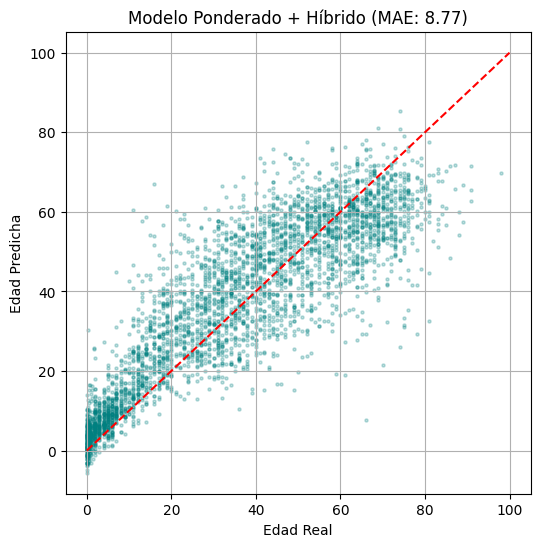

In [ ]:
# ================================================
# 1. IMPORTS + CONFIGURACIÓN
# ================================================
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import mixed_precision
from google.colab import drive
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

print(f"TF version: {tf.__version__}")
mixed_precision.set_global_policy("mixed_float16")
tf.config.optimizer.set_jit(True)

# ================================================
# 2. CARGA DE DATOS
# ================================================
drive.mount("/content/drive", force_remount=False)
TFRECORD_FILE = "/content/drive/MyDrive/Proyecto_Final_IA_Starita_Meneghini/output.tfrecord"

AUTOTUNE = tf.data.AUTOTUNE

feature_description = {
    "data":       tf.io.VarLenFeature(tf.float32),
    "age":        tf.io.FixedLenFeature([], tf.float32),
    "vent_rate":  tf.io.FixedLenFeature([], tf.int64),
    "sex":        tf.io.FixedLenFeature([], tf.string),
    "qrs":        tf.io.FixedLenFeature([], tf.int64),
    "pr_interval":tf.io.FixedLenFeature([], tf.int64),
    "QT":         tf.io.FixedLenFeature([], tf.int64),
    "QTc":        tf.io.FixedLenFeature([], tf.int64),
    "P":          tf.io.FixedLenFeature([], tf.int64),
}

META_KEYS = ["vent_rate", "qrs", "pr_interval", "QT", "QTc", "P"]

def _parse_fn(example_proto):
    f = tf.io.parse_single_example(example_proto, feature_description)
    x = tf.sparse.to_dense(f["data"])
    x = tf.reshape(x, (12, 640))
    x = tf.transpose(x, perm=[1, 0])
    # Normalización ECG
    mean = tf.reduce_mean(x, axis=0, keepdims=True)
    std  = tf.math.reduce_std(x, axis=0, keepdims=True)
    x = (x - mean) / (std + 1e-6)
    # Age
    age = f["age"]
    # Meta
    meta_vals = [tf.cast(f[k], tf.float32) for k in META_KEYS]
    meta_numeric = tf.stack(meta_vals, axis=0)
    sex_val = tf.where(tf.equal(f["sex"], tf.constant(b"Male")), 1.0, 0.0)
    sex_val = tf.reshape(sex_val, [1])
    meta = tf.concat([meta_numeric, sex_val], axis=0)
    return x, meta, age

# Cargar
raw_ds = tf.data.TFRecordDataset(TFRECORD_FILE)
parsed_ds = raw_ds.map(_parse_fn, num_parallel_calls=AUTOTUNE)
TOTAL = parsed_ds.reduce(tf.constant(0, dtype=tf.int64), lambda acc, _: acc + 1).numpy()
TOTAL = int(TOTAL)
print(f"Total muestras: {TOTAL}")

# ================================================
# 3. SPLIT Y ESTADÍSTICAS
# ================================================
parsed_ds = tf.data.TFRecordDataset(TFRECORD_FILE).map(_parse_fn, num_parallel_calls=AUTOTUNE)
parsed_ds = parsed_ds.shuffle(TOTAL, reshuffle_each_iteration=False)

train_size = int(TOTAL * 0.70)
val_size   = int(TOTAL * 0.15)
test_size  = TOTAL - train_size - val_size

train_base = parsed_ds.take(train_size)
val_base   = parsed_ds.skip(train_size).take(val_size)
test_base  = parsed_ds.skip(train_size + val_size).take(test_size)

print("Calculando estadísticas de Train...")
ages_list = []
meta_list = []
for x, m, a in train_base:
    ages_list.append(a.numpy())
    meta_list.append(m.numpy())

ages_arr = np.array(ages_list).astype("float32")
meta_arr = np.stack(meta_list, axis=0).astype("float32")

AGE_MEAN = ages_arr.mean()
AGE_STD  = ages_arr.std()
meta_mean = meta_arr.mean(axis=0)
meta_std  = meta_arr.std(axis=0)
meta_std_safe = np.where(meta_std < 1e-6, 1.0, meta_std)

print(f"Edad Media: {AGE_MEAN:.2f}, Std: {AGE_STD:.2f}")

# ================================================
# 4. CÁLCULO DE PESOS (SAMPLE WEIGHTS)
# ================================================
print("Calculando pesos manuales...")
age_bins_indices = np.digitize(ages_arr, bins=np.arange(0, 101, 5))
bin_counts = np.bincount(age_bins_indices, minlength=22)

max_count = np.max(bin_counts[1:])
weights_manual = np.ones(len(bin_counts), dtype=np.float32)

for i in range(1, len(bin_counts)):
    count = bin_counts[i]
    if count > 0:
        w = np.sqrt(max_count / count)
        weights_manual[i] = min(w, 5.0) # Clamping
    else:
        weights_manual[i] = 1.0

WEIGHTS_TF = tf.constant(weights_manual, dtype=tf.float32)

# ================================================
# 5. PIPELINE ROBUSTO (INFINITO)
# ================================================
def normalize_all(x, meta, age):
    y = (age - AGE_MEAN) / AGE_STD
    meta_norm = (meta - meta_mean) / meta_std_safe
    return x, meta_norm, y

def to_multimodal(x, meta, y):
    return (x, meta), y

def add_sample_weight_robust(inputs, y):
    age_real = (y * AGE_STD) + AGE_MEAN
    bin_idx = tf.cast(age_real / 5.0, tf.int32) + 1
    bin_idx = tf.clip_by_value(bin_idx, 0, len(weights_manual) - 1)
    w = tf.gather(WEIGHTS_TF, bin_idx)
    return inputs, y, w

# Normalizar base
train_norm = train_base.map(normalize_all, num_parallel_calls=AUTOTUNE)
val_norm   = val_base.map(normalize_all, num_parallel_calls=AUTOTUNE)
test_norm  = test_base.map(normalize_all, num_parallel_calls=AUTOTUNE)

BATCH_SIZE = 64

# --- TRAIN (Pipeline Infinito corregido) ---
train_final = train_norm.map(to_multimodal, num_parallel_calls=AUTOTUNE)
train_final = train_final.map(add_sample_weight_robust, num_parallel_calls=AUTOTUNE)
train_final = train_final.shuffle(2000)
train_final = train_final.repeat() # <--- REPEAT ANTES DE BATCH
train_final = train_final.batch(BATCH_SIZE)
train_final = train_final.prefetch(AUTOTUNE)

# --- VAL & TEST ---
val_final = val_norm.map(to_multimodal, num_parallel_calls=AUTOTUNE)
val_final = val_final.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_final = test_norm.map(to_multimodal, num_parallel_calls=AUTOTUNE)
test_final = test_final.batch(BATCH_SIZE).prefetch(AUTOTUNE)

steps_per_epoch = train_size // BATCH_SIZE

# ================================================
# 6. MODELO: HYBRID POOLING (AVG + MAX)
# ================================================
def transformer_encoder(x, num_heads, proj_dim, ff_dim, dropout=0.1):
    x_norm = layers.LayerNormalization()(x)
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=proj_dim, dropout=dropout)(x_norm, x_norm)
    x_res = layers.Add()([x, attn_output])
    x_norm2 = layers.LayerNormalization()(x_res)
    ff = layers.Dense(ff_dim, activation="gelu")(x_norm2)
    ff = layers.Dense(proj_dim, activation=None)(ff)
    x_out = layers.Add()([x_res, ff])
    return x_out

def build_model(ecg_shape=(640, 12), meta_dim=7):
    ecg_in  = layers.Input(shape=ecg_shape, name="ecg")
    meta_in = layers.Input(shape=(meta_dim,), name="meta")

    # CNN Front-end
    x = layers.LayerNormalization()(ecg_in)
    x = layers.Conv1D(64, 7, padding="same", activation="relu")(x)
    x = layers.Conv1D(64, 7, padding="same", activation="relu")(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 5, padding="same", activation="relu")(x)
    x = layers.Conv1D(128, 5, padding="same", activation="relu")(x)
    x = layers.MaxPooling1D(2)(x)

    proj_dim = 128
    x = layers.Dense(proj_dim)(x)

    # Transformer
    for _ in range(3):
        x = transformer_encoder(x, num_heads=4, proj_dim=proj_dim, ff_dim=256, dropout=0.1)

    # HYBRID POOLING (La clave de la mejora)
    avg_pool = layers.GlobalAveragePooling1D()(x)
    max_pool = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([avg_pool, max_pool])

    # Meta + Fusion
    m = layers.Dense(32, activation="relu")(meta_in)
    m = layers.Dense(16, activation="relu")(m)

    h = layers.Concatenate()([x, m])
    h = layers.Dense(64, activation="relu")(h)
    h = layers.Dropout(0.3)(h)
    h = layers.Dense(32, activation="relu")(h)
    out = layers.Dense(1, dtype="float32")(h)

    return models.Model([ecg_in, meta_in], out, name="Final_Model_Weighted")

# ================================================
# 7. ENTRENAMIENTO (MODEL_WEIGHTED)
# ================================================
model_weighted = build_model()

# Optimizador seguro para evitar explosiones por los pesos
optimizer_safe = tf.keras.optimizers.Adam(learning_rate=2e-5, global_clipnorm=1.0)

model_weighted.compile(optimizer=optimizer_safe, loss="mse", metrics=["mae"])

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=7, monitor="val_loss", restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.3, min_lr=1e-6)
]

print("🟢 Entrenando model_weighted...")
history_weighted = model_weighted.fit(
    train_final,
    validation_data=val_final,
    epochs=30,
    steps_per_epoch=steps_per_epoch,
    callbacks=callbacks
)

# ================================================
# 8. EVALUACIÓN CORRECTA (ATÓMICA)
# ================================================
print("🔎 Extrayendo TEST en arrays estáticos...")

X_ecg_list = []
X_meta_list = []
y_list = []

# UNBATCH es la clave para evitar el desorden
for (ecg, meta), y in test_final.unbatch():
    X_ecg_list.append(ecg.numpy())
    X_meta_list.append(meta.numpy())
    y_list.append(y.numpy())

X_ecg  = np.stack(X_ecg_list, axis=0).astype("float32")
X_meta = np.stack(X_meta_list, axis=0).astype("float32")
y_true_norm = np.array(y_list).astype("float32").flatten()

print(f"✅ Datos extraídos: {X_ecg.shape}")
print("🔎 Ejecutando predicción model_weighted...")

y_pred_norm = model_weighted.predict([X_ecg, X_meta], verbose=1).flatten()

# Desnormalizar
y_pred = y_pred_norm * AGE_STD + AGE_MEAN
y_true = y_true_norm * AGE_STD + AGE_MEAN

mae = mean_absolute_error(y_true, y_pred)
r2  = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"\n🏆 RESULTADO DEFINITIVO:")
print(f"✅ MAE : {mae:.4f} años")
print(f"✅ RMSE: {rmse:.4f} años")
print(f"✅ R²  : {r2:.4f}")

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.25, s=5, color='teal')
plt.plot([0, 100], [0, 100], 'r--')
plt.xlabel("Edad Real"); plt.ylabel("Edad Predicha")
plt.title(f"Modelo Ponderado + Híbrido (MAE: {mae:.2f})")
plt.grid(True)
plt.show()

✅ MAE : 8.7653 años
✅ RMSE: 11.5963 años
✅ R²  : 0.7680

🔄 Generando predicciones en Test...
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step
Shapes: y_true=(3738,), y_pred=(3738,)


====== 📊 TABLA DE MÉTRICAS (TEST, en años) ======



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


,MAE,RMSE,R²,MAPE,MedAE,Pearson r,Spearman ρ
Modelo Híbrido (Weighted),8.765329,11.596342,0.768003,197.099625,6.679875,0.878564,0.878551


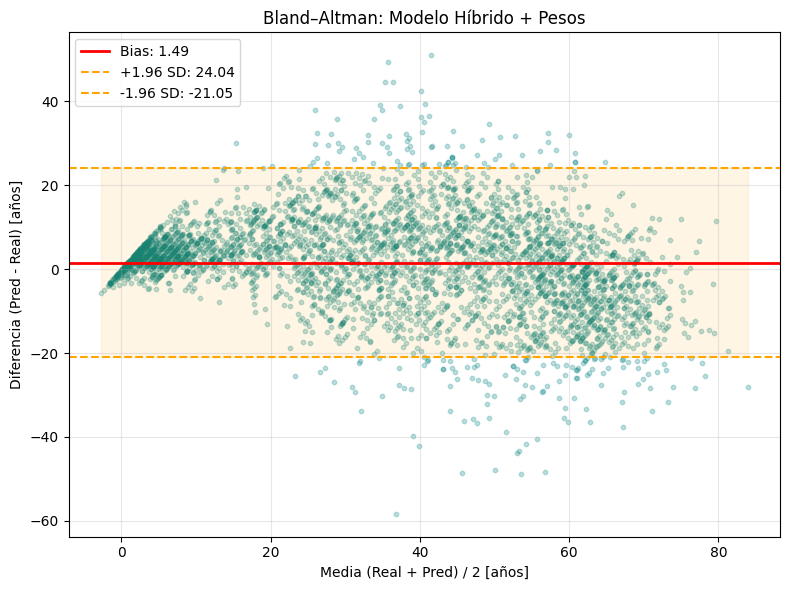

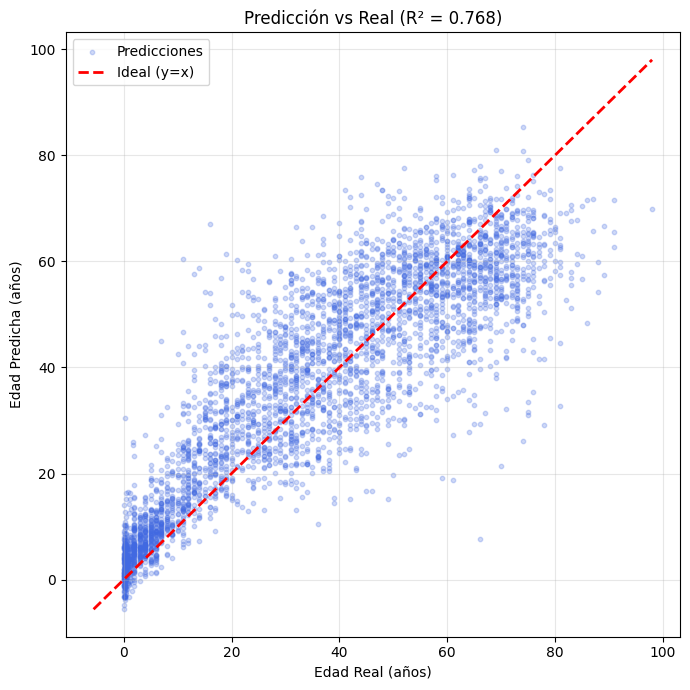

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

# ================================================
# 1) Extraer y_true normalizado desde test_final
# ================================================
y_true_norm_list = []

# Iteramos sobre el dataset de test para sacar las etiquetas reales
for batch in test_final:
    # test_final devuelve ((x, meta), y) -> nos interesa solo y
    _, y_batch = batch
    y_true_norm_list.append(y_batch.numpy())

y_true_norm = np.concatenate(y_true_norm_list, axis=0).reshape(-1)

# ================================================
# 2) Predicciones NORMALIZADAS del modelo actual
# ================================================
print("🔄 Generando predicciones en Test...")

# Usamos el modelo que acabamos de entrenar (model_weighted)
y_pred_norm = model_weighted.predict(test_final, verbose=1).reshape(-1)

print(f"Shapes: y_true={y_true_norm.shape}, y_pred={y_pred_norm.shape}")

# ================================================
# 3) Desnormalizar TODO a años reales
# ================================================
y_true_real = y_true_norm * AGE_STD + AGE_MEAN
y_pred_real = y_pred_norm * AGE_STD + AGE_MEAN

# ================================================
# 4) Función de métricas en AÑOS
# ================================================
def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    # Evitar división por cero en MAPE
    safe_y_true = np.where(y_true == 0, 1e-6, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / safe_y_true)) * 100

    medae = np.median(np.abs(y_true - y_pred))
    pearson_r, _  = stats.pearsonr(y_true, y_pred)
    spearman_r, _ = stats.spearmanr(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "MAPE": mape,
        "MedAE": medae,
        "Pearson r": pearson_r,
        "Spearman ρ": spearman_r,
    }

metrics_weighted = compute_metrics(y_true_real, y_pred_real)

# ================================================
# 5) Mostrar Tabla de Métricas
# ================================================
df_metrics = pd.DataFrame({
    "Modelo Híbrido (Weighted)": metrics_weighted
})

print("\n\n====== 📊 TABLA DE MÉTRICAS (TEST, en años) ======\n")
display(df_metrics.T) # Transponemos para leer mejor

# ================================================
# 6) Bland–Altman
# ================================================
def bland_altman_stats(y_true, y_pred):
    diff = y_pred - y_true
    bias = np.mean(diff)
    sd   = np.std(diff, ddof=1)
    loa_hi = bias + 1.96 * sd
    loa_lo = bias - 1.96 * sd
    return bias, loa_hi, loa_lo, diff

def bland_altman_plot(ax, y_true, y_pred, title="Bland–Altman"):
    means = (y_true + y_pred) / 2.0
    bias, loa_hi, loa_lo, diff = bland_altman_stats(y_true, y_pred)

    ax.scatter(means, diff, alpha=0.25, s=10, color='teal')
    ax.axhline(bias, color='red', linestyle="-", linewidth=2, label=f"Bias: {bias:.2f}")
    ax.axhline(loa_hi, color='orange', linestyle="--", label=f"+1.96 SD: {loa_hi:.2f}")
    ax.axhline(loa_lo, color='orange', linestyle="--", label=f"-1.96 SD: {loa_lo:.2f}")

    # Relleno para zona de acuerdo
    ax.fill_between([min(means), max(means)], loa_lo, loa_hi, color='orange', alpha=0.1)

    ax.set_xlabel("Media (Real + Pred) / 2 [años]")
    ax.set_ylabel("Diferencia (Pred - Real) [años]")
    ax.set_title(title)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

# Graficamos
fig, ax = plt.subplots(figsize=(8, 6))
bland_altman_plot(ax, y_true_real, y_pred_real, title="Bland–Altman: Modelo Híbrido + Pesos")
plt.tight_layout()
plt.show()

# ================================================
# 7) Scatter Predicción vs Real
# ================================================
plt.figure(figsize=(7, 7))

plt.scatter(y_true_real, y_pred_real, alpha=0.25, s=10, color='royalblue', label="Predicciones")

# Línea de identidad
min_val = min(y_true_real.min(), y_pred_real.min())
max_val = max(y_true_real.max(), y_pred_real.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Ideal (y=x)")

plt.xlabel("Edad Real (años)")
plt.ylabel("Edad Predicha (años)")
plt.title(f"Predicción vs Real (R² = {metrics_weighted['R²']:.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

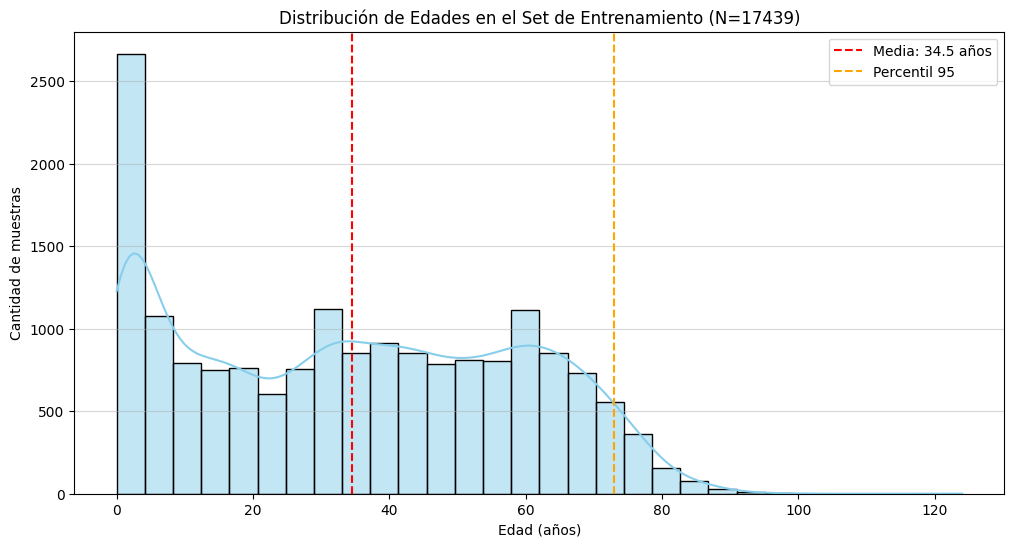

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Histograma con curva de densidad (KDE)
sns.histplot(ages_arr, bins=30, kde=True, color='skyblue', edgecolor='black')

# Líneas de referencia
plt.axvline(ages_arr.mean(), color='red', linestyle='--', label=f'Media: {ages_arr.mean():.1f} años')
plt.axvline(np.percentile(ages_arr, 95), color='orange', linestyle='--', label='Percentil 95')

plt.title(f'Distribución de Edades en el Set de Entrenamiento (N={len(ages_arr)})')
plt.xlabel('Edad (años)')
plt.ylabel('Cantidad de muestras')
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

## ❌ Error Metodológico en la Evaluación por "Doble Pasada"

El código es incorrecto porque invoca al generador de datos `tf.data` en **dos instancias independientes**  
(una iteración manual para extraer `y_true` y otra interna al llamar a `model.predict`), lo cual **rompe la integridad de la evaluación** cuando se usa carga paralela con `AUTOTUNE`.

Debido a que el procesamiento multihilo **no garantiza un orden determinista de salida** por condiciones de carrera en la CPU, es altamente probable que ocurra **desalineación de los datos**, donde la etiqueta real de un sujeto (ej. *"Paciente A"*) se compare erróneamente contra la predicción de otro (ej. *"Paciente B"*).

Para evitar este ruido y obtener métricas fiables, es obligatorio realizar una **extracción atómica** a arreglos estáticos de NumPy en **una única pasada**, garantizando así que cada entrada mantenga su **correspondencia 1:1** con su etiqueta.


In [ ]:
# ================================================
# 8. EVALUACIÓN FINAL
# ================================================
print("🔎 Evaluando en TEST...")
y_pred_norm = model.predict(test_final, verbose=1).flatten()
y_true_norm = np.concatenate([y.numpy() for (x,m), y in test_final], axis=0).flatten()

y_pred = y_pred_norm * AGE_STD + AGE_MEAN
y_true = y_true_norm * AGE_STD + AGE_MEAN

mae = mean_absolute_error(y_true, y_pred)
r2  = r2_score(y_true, y_pred)

print(f"✅ MAE Final: {mae:.4f} años")
print(f"✅ R² Final:  {r2:.4f}")

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.3, s=5)
plt.plot([0, 100], [0, 100], 'r--')
plt.xlabel("Edad Real"); plt.ylabel("Edad Predicha")
plt.title(f"MAE: {mae:.2f}")
plt.grid(True)
plt.show()